In [5]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_excel('SCI-2025_v1.0_pathways_ensemble_global.xlsx', sheet_name='data')

# Strip whitespace from column names (common cause of KeyError)
df.columns = df.columns.str.strip()

print("Columns found:", df.columns.tolist())
print("Shape:", df.shape)

# ── Config ────────────────────────────────────────────────────────────────────
target_vars = [
    'Emissions|CO2',
    'Final Energy',
    'Primary Energy',
    'Population',
    'Food Availability [per capita]',
    'Agricultural Demand|Crops',
    'Price|Carbon',
    'Capacity|Electricity|Fossil',
    'Capacity|Electricity|Biomass',
    'Capacity|Electricity|Non-Biomass Renewables',
]

# Auto-detect year columns (numeric column names like 2020, 2030, etc.)
year_cols = [c for c in df.columns if str(c).strip().isdigit()]
print("Year columns detected:", year_cols)

# Use last year if multiple, or whichever you prefer
# Change this to e.g. 2050 if you want a specific year
value_col = year_cols[-1] if year_cols else '2070'
print("Using year column:", value_col)

# ── Filter & Pivot ────────────────────────────────────────────────────────────
filtered = df[df['Variable'].isin(target_vars)].copy()

missing = set(target_vars) - set(filtered['Variable'].unique())
if missing:
    print("Warning: these variables not found in data:", missing)

pivot = filtered.pivot_table(
    index=['Model', 'Scenario'],
    columns='Variable',
    values=value_col,
    aggfunc='first'
).reset_index()

col_order = ['Model', 'Scenario'] + [v for v in target_vars if v in pivot.columns]
pivot = pivot[col_order]
units = filtered.groupby('Variable')['Unit'].first().to_dict()

print(f"Output shape: {pivot.shape}")

# ── Write & Format ─────────────────────────────────────────────────────────────
output_path = 'SCI_2025_reshaped_rows.xlsx'
pivot.to_excel(output_path, index=False, sheet_name='Data')

wb = load_workbook(output_path)
ws = wb['Data']

header_fill = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
header_font = Font(bold=True, color='FFFFFF', name='Arial', size=10)
center = Alignment(horizontal='center', vertical='center', wrap_text=True)
thin = Side(style='thin', color='CCCCCC')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

for cell in ws[1]:
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center
    cell.border = border

# Insert units row
ws.insert_rows(2)
unit_fill = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
unit_font = Font(italic=True, color='1F4E79', name='Arial', size=9)
ws['A2'] = 'Units:'
ws['A2'].font = Font(bold=True, italic=True, name='Arial', size=9, color='1F4E79')
ws['A2'].fill = unit_fill

for col_idx, col_name in enumerate(pivot.columns, 1):
    cell = ws.cell(row=2, column=col_idx)
    if col_name in units:
        cell.value = units[col_name]
    cell.font = unit_font
    cell.fill = unit_fill
    cell.alignment = center
    cell.border = border

alt_fill = PatternFill('solid', start_color='EBF3FB', end_color='EBF3FB')
white_fill = PatternFill('solid', start_color='FFFFFF', end_color='FFFFFF')
data_font = Font(name='Arial', size=10)

for row_idx, row in enumerate(ws.iter_rows(min_row=3, max_row=ws.max_row), 1):
    fill = alt_fill if row_idx % 2 == 0 else white_fill
    for col_idx, cell in enumerate(row, 1):
        cell.font = data_font
        cell.fill = fill
        cell.border = border
        if col_idx > 2 and cell.value is not None:
            cell.number_format = '#,##0.00'
            cell.alignment = Alignment(horizontal='right')
        else:
            cell.alignment = Alignment(horizontal='left')

ws.column_dimensions['A'].width = 22
ws.column_dimensions['B'].width = 14
for col_idx in range(3, len(pivot.columns) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 24

ws.freeze_panes = 'C3'
ws.row_dimensions[1].height = 40
wb.save(output_path)
print(f"Done → {output_path}")

Columns found: ['Model', 'Scenario', 'Region', 'Variable', 'Unit', '2010', '2015', '2020', '2025', '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Shape: (548541, 24)
Year columns detected: ['2010', '2015', '2020', '2025', '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Using year column: 2100
Output shape: (1573, 12)
Done → SCI_2025_reshaped_rows.xlsx


In [20]:
import pandas as pd

data = pd.read_excel(
    "SCI_2025_reshaped_rows.xlsx",
    sheet_name="Data"
)

# Remove units row
data = data.iloc[1:].reset_index(drop=True)

# Convert all columns except Model and Scenario
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values
#data = data.dropna()

print(data.shape)
print(data.dtypes)

(1573, 12)
Model                                           object
Scenario                                        object
Emissions|CO2                                  float64
Final Energy                                   float64
Primary Energy                                 float64
Population                                     float64
Food Availability [per capita]                 float64
Agricultural Demand|Crops                      float64
Price|Carbon                                   float64
Capacity|Electricity|Fossil                    float64
Capacity|Electricity|Biomass                   float64
Capacity|Electricity|Non-Biomass Renewables    float64
dtype: object


In [21]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Population,Food Availability [per capita],Agricultural Demand|Crops,Price|Carbon,Capacity|Electricity|Fossil,Capacity|Electricity|Biomass,Capacity|Electricity|Non-Biomass Renewables
0,AIM/CGE 2.0,SSP1-19,-4474.874100,311.634100,390.247600,6881.584600,3271.7909,4439.7738,2398.749760,492.153200,973.388900,24974.216700
1,AIM/CGE 2.0,SSP1-26,17.737700,326.197800,447.017100,6881.584600,3339.8633,4523.5270,423.880820,1716.053800,918.052000,18858.271600
2,AIM/CGE 2.0,SSP1-34,9037.781800,348.457500,493.885900,6881.584600,3358.8652,4575.0774,112.680370,2198.864000,1309.429400,15602.858900
3,AIM/CGE 2.0,SSP1-45,18738.134600,361.338100,508.013900,6881.584600,3369.8110,4582.8676,42.858200,2920.712600,1115.203700,13714.074200
4,AIM/CGE 2.0,SSP1-Baseline,29879.805400,387.116000,576.536600,6881.584600,3378.7550,4593.6824,NaN,4539.632500,1038.480100,12250.503000
...,...,...,...,...,...,...,...,...,...,...,...,...
1568,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-8298.142767,481.152565,801.779905,8943.236681,NaN,NaN,2301.616255,913.163188,1690.623180,38710.515716
1569,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,-1964.924847,521.502532,860.832783,8943.236681,NaN,NaN,1189.180974,1224.005639,1509.450800,36522.817178
1570,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-14222.971415,445.931529,758.458933,8943.236681,NaN,NaN,5620.664725,617.490159,2301.258906,40023.243319
1571,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,79704.641306,695.758625,1266.199768,8943.236681,NaN,NaN,0.946701,6850.003974,100.337914,20822.715195


In [22]:
outcome_interest = 2
factors = [2] + list(range(5, 10))
#factors = [6, 7, 8, 9]

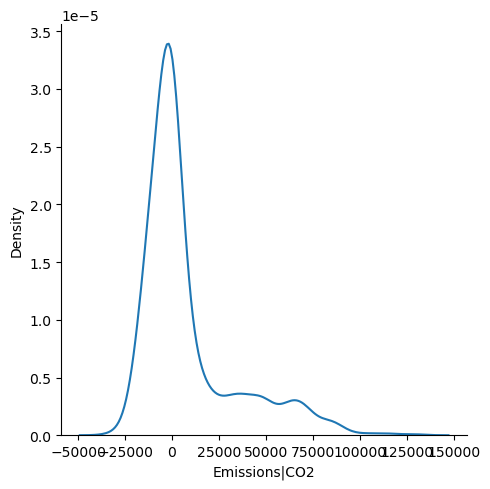

In [23]:

import seaborn as sns
sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [24]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values<threshold_interest

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 783 cases of interest, out of 1573 scenarios


In [28]:
!pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)


In [30]:
from ema_workbench.analysis import cart

cart_alg = cart.CART(x, y)
cart_alg.build_tree()

fig = cart_alg.show_tree()
fig.set_size_inches((18, 12))
plt.show()

FileNotFoundError: [WinError 2] "dot" not found in path.